### Code for exploring EmoDB dataset

In [2]:
import os 

os.chdir(r"C:\path\to\file\emodb\wav")

wav_files = [f for f in os.listdir(".") if f.endswith(".wav")]
print(len(wav_files))

535


In [2]:
import audformat
import pandas as pd
db = audformat.Database.load(r"C:\path\to\file\emodb\wav")

df_test = db['emotion.categories.test.gold_standard'].get()

df_train = db['emotion.categories.train.gold_standard'].get()

df_whole = pd.concat([df_train, df_test])

#### Getting a basic idea about the EmoDB dataset

In [3]:
df_whole.describe(include="all")

,emotion,emotion.confidence
count,535,535.000000
unique,7,NaN
top,anger,NaN
freq,127,NaN
mean,NaN,0.935399
std,NaN,0.062964
min,NaN,0.800000
25%,NaN,0.900000
50%,NaN,0.950000
75%,NaN,1.000000


>> Finding: The dataset has 7 cats, anger is the most represented one and regarding the confidence level with which people assigned the emotion label to the individual wav files: the dataset only includes assignments where the participant was minimum 80% confident that emotion x belonged to wav file n. the good quality of the groundtruth labels is also highlighted by a mean confidence about their choice of 93.5% with only a variation of +- 6.3%

#### Visualising how reliable the emotion labels assigned to the wav files actually are

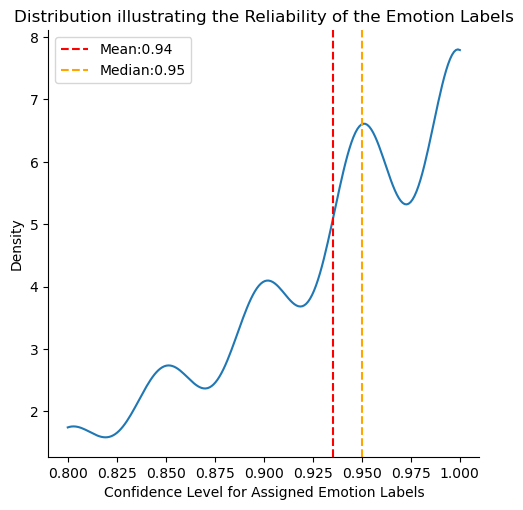

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.displot(df_whole["emotion.confidence"], kind="kde", cut=0)
plt.axvline(df_whole["emotion.confidence"].mean(), linestyle="--", color= "r", label=f"Mean:{df_whole['emotion.confidence'].mean():.2f}")
plt.axvline(df_whole["emotion.confidence"].median(), linestyle="--", color= "orange", label=f"Median:{df_whole['emotion.confidence'].median():.2f}")
plt.xlabel("Confidence Level for Assigned Emotion Labels")
plt.legend()
plt.title("Distribution illustrating the Reliability of the Emotion Labels")
plt.show()

#### Checking for class (im)balance

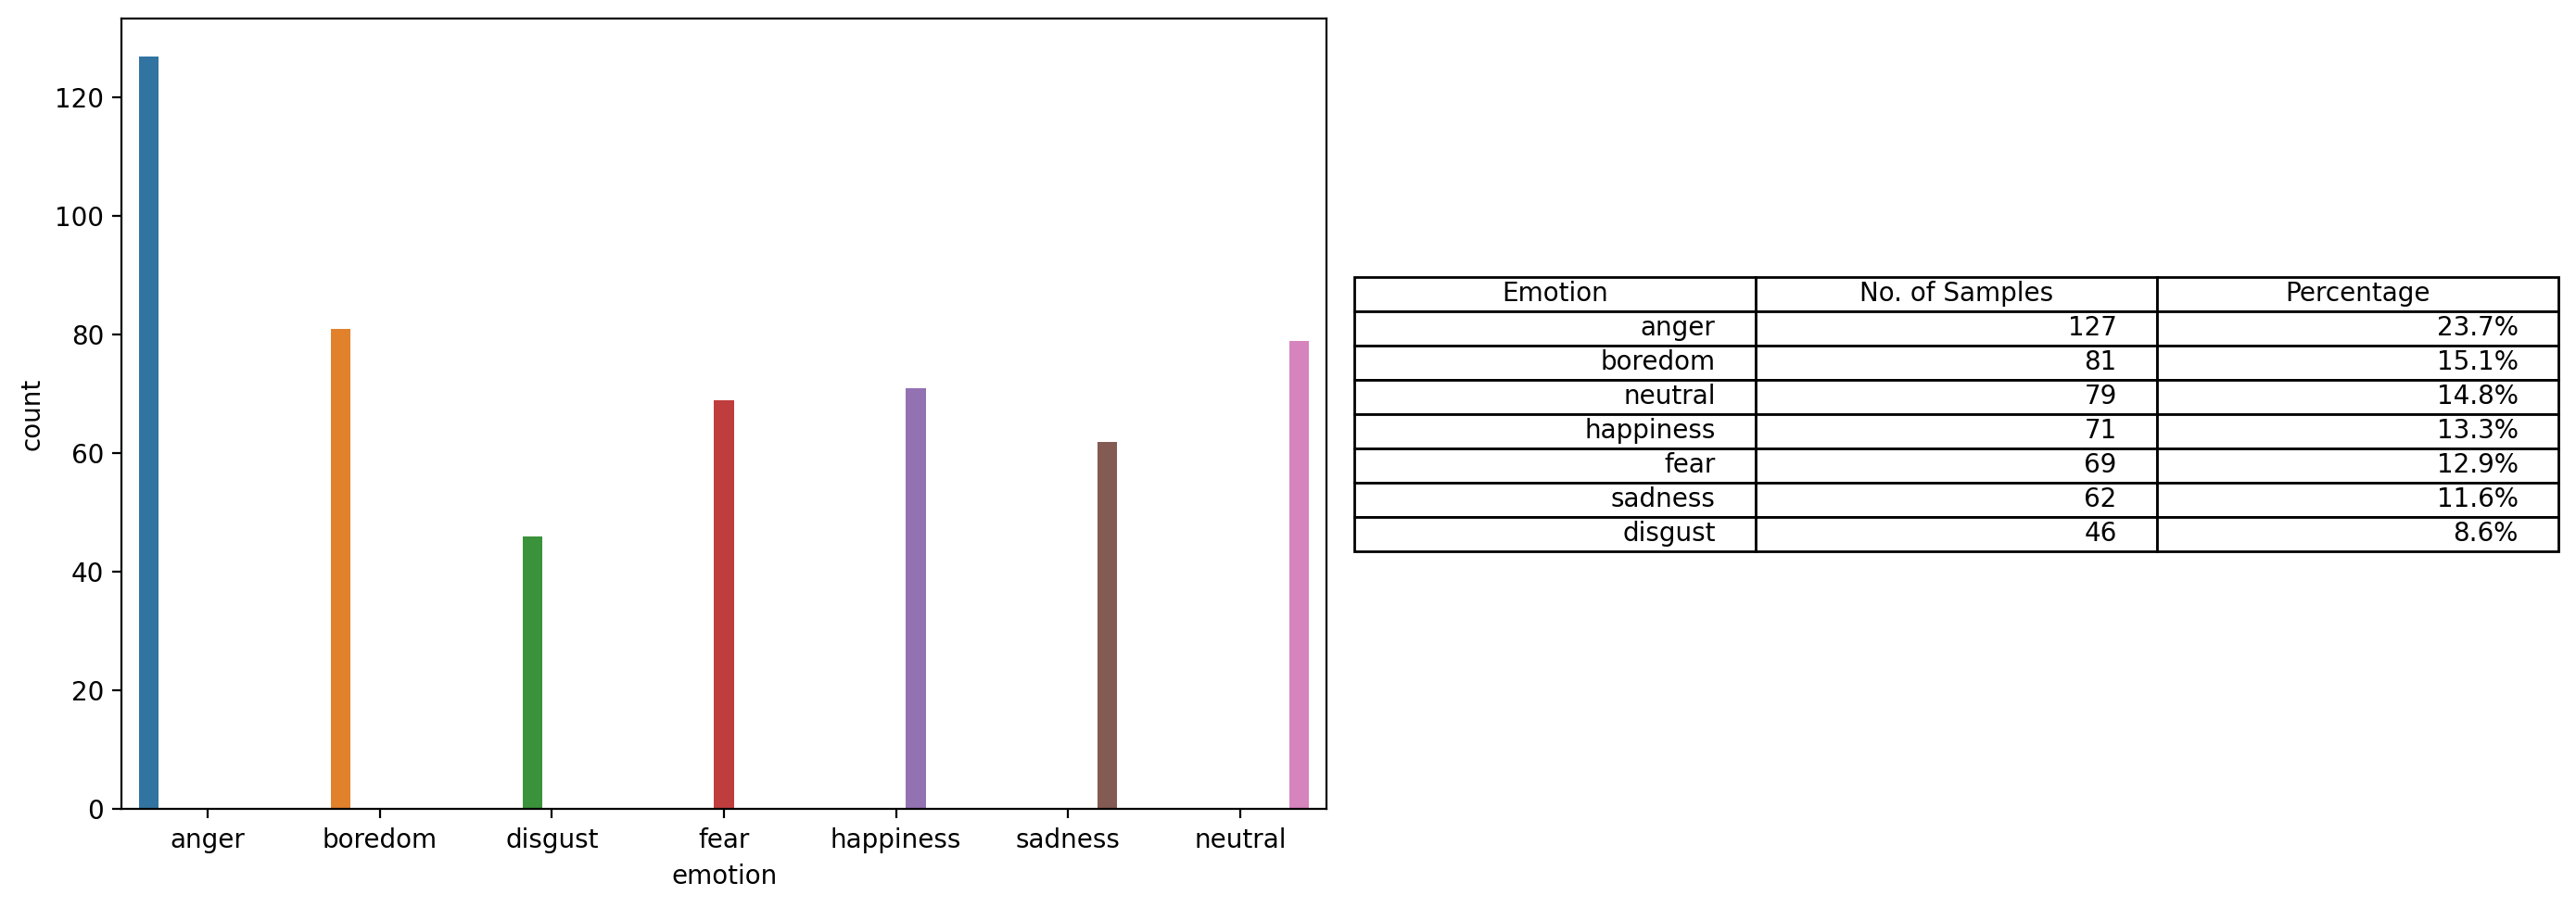

In [6]:
fig, axes = plt.subplots(1,2, figsize=(14,5), dpi=200)

emotion_dist = sns.countplot(data= df_whole, x="emotion", hue="emotion", ax=axes[0])
emotion_val_counts = df_whole["emotion"].value_counts().reset_index()
emotion_val_counts["precentage"] = (emotion_val_counts["count"] / len(wav_files) *100).round(1).astype(str) + "%"
axes[1].axis("off")
axes[1].table(cellText= emotion_val_counts.values, colLabels= ["Emotion", "No. of Samples", "Percentage"], loc= "center")

plt.tight_layout()
plt.savefig(r"C:\file\to\save\EmoDB_Emo_Distrbution.png")
plt.show()

>> Finding: anger is severely overrepresented, while disguts is extremely underrepresented (more than 2.5 times less in dataset than anger), while the other categories are sampled alrightish (for total dataset of 535 files, ideal size would have been 76.4 per cat)

#### Checking for Gender representation within the dataset as a whole and within the individual emotion cats

In [8]:
df_speaker = db['speaker'].get()
print(db['speaker'].df)  

         age  gender language
speaker                      
3         31    male      deu
8         34  female      deu
9         21  female      deu
10        32    male      deu
11        26    male      deu
12        30    male      deu
13        32  female      deu
14        35  female      deu
15        25    male      deu
16        31  female      deu


In [9]:
female_speakers = [8,9,13,14,16]
male_speakers= [3,10,11,12,15]

df_whole_speaker = df_whole.copy()
df_whole_speaker["speaker"] = (
    df_whole_speaker.index.get_level_values(0).str[4:6].astype(int))

df_whole_speaker["gender"]= df_whole_speaker["speaker"].map({speaker: "male" for speaker in male_speakers} | {speaker: "female" for speaker in female_speakers})

In [10]:
gender_per_emotion = (
    df_whole_speaker.groupby(["emotion", "gender"]).size().unstack(fill_value=0))

gender_per_emotion.loc["Total"] = gender_per_emotion.sum()
gender_perc = gender_per_emotion.div(gender_per_emotion.sum(axis=1), axis=0)*100

comb_numbers = gender_per_emotion.astype(str) + " ("+gender_perc.round(1).astype(str)+ "%)"

print(comb_numbers)

gender          female         male
emotion                            
anger       67 (52.8%)   60 (47.2%)
boredom     46 (56.8%)   35 (43.2%)
disgust     35 (76.1%)   11 (23.9%)
fear        33 (47.8%)   36 (52.2%)
happiness   44 (62.0%)   27 (38.0%)
sadness     37 (59.7%)   25 (40.3%)
neutral     40 (50.6%)   39 (49.4%)
Total      302 (56.4%)  233 (43.6%)


>> Findings: on the overall dataset, female recordings are slightly overrepresented; especially in "disgust" and "happiness", the gap is quite wide between the female recordings dominating and the included male recordings. the only almost balanced amount of recordings as per gender can be found in "neutral", closely followed by "anger" and "fear", whereas the gap for the reamining categories is noticable, it is still moderate compared to  "disgust" and "happiness"

### Checking for the Quality of the wav files

#### a) Checking whether the files are corrupted and/or clipped 

In [11]:
#(1) Checking bit size across files 
from collections import Counter 
import soundfile as sf
from pathlib import Path 

wav_dir = r"C:\path\to\file\emodb\wav"
bit_sizes= Counter(int(sf.info(wav).subtype.split("_")[1]) for wav in Path(wav_dir).glob("*.wav"))

print(bit_sizes)

Counter({16: 535})


In [12]:
#(2) since we are dealing with wav files, which use  PCM (Pulse Code Modulation) and PCM stores int, 
#    namely within a range of -32768 and +32767; using soundfile, this is normalised to 0.999969 by taking 32767 / 32768
import numpy as np

def corrpution_clipping_detection(wav_dir, clip_treshold=0.999969):
    results = []
    for wav in Path(wav_dir).glob("*.wav"):
        try: 
            data, sampling_rate = sf.read(wav)
            clipped = np.mean(np.abs(data)> clip_treshold)
            results.append({
                "file": wav.name, 
                "sampling rate": sampling_rate, 
                "duration": len(data)/sampling_rate, 
                "clip_ratio": clipped, 
                "corrupt": False})

        except Exception as e: 
            results.append({"file": wav.name, "corrupt": True, "error": str(e)})
    return results 

results = corrpution_clipping_detection(wav_dir)
df_results = pd.DataFrame(results)
print(df_results[df_results["corrupt"] == True])
print(df_results[df_results["clip_ratio"] > 0.001]) #flags files as clipped if 0.1% of the samples within the file have reached the clip_treshold

Empty DataFrame
Columns: [file, sampling rate, duration, clip_ratio, corrupt]
Index: []
Empty DataFrame
Columns: [file, sampling rate, duration, clip_ratio, corrupt]
Index: []


>> Finding: Since empty data frames are returned for the corrputed files and the clipped files, this means that the quality of the audio files is high (all files can be read within any issues, nor there is any significant clipping); relfects the recording conditions in the studio (see original paper)

#### b) the ratio betwqeen speech and background noise in the files

In [13]:
from scipy.io import wavfile

def sound_noise_ratio(audio_data, sample_rate, snr_treshold= 20.0, frame_duration=0.02):  
    if len(audio_data.shape) > 1:   #making sure not only mono but also stereo can be handled
        audio_data = np.mean(audio_data, axis=1)

    audio_data = audio_data.astype(np.float64)
    frame_size= int(frame_duration*sample_rate)
    frame_number = len(audio_data) // frame_size

    sound_intensity_frame = [np.var(audio_data[i*frame_size : (i+1)*frame_size]) for i in range(frame_number)]
    sound_intensity_frame = np.array(sound_intensity_frame)

    noise_intensity = np.percentile(sound_intensity_frame, 15)
    speech_intensity = np.percentile(sound_intensity_frame, 50)

    if noise_intensity == 0: 
        noise_intensity = 1e-10  #to avoid zero devision

    #formula: SNR(dB) = 10*log10(signal power/noise power)
    snr_db = 10*np.log10(speech_intensity/noise_intensity)

    is_noisy = snr_db < snr_treshold

    return round(snr_db,2), is_noisy  

In [14]:
total_files = len(wav_files)
clean_files = []
noisy_files = []

for filename in wav_files: 
    try: 
        sample_rate, audio_data = wavfile.read(filename)
        snr_db, is_noisy = sound_noise_ratio(audio_data, sample_rate, snr_treshold= 20.0, frame_duration=0.02)
        if is_noisy: 
            noisy_files.append((filename, snr_db))
        else: 
            clean_files.append((filename, snr_db))
    except Exception as e: 
        print(f"{filename} could not be read due to {e}")

noisy_file_count = len(noisy_files)
clean_file_count = len(clean_files)

noisy_perc = (noisy_file_count / total_files) * 100
print(f"Noisy files found: {noisy_file_count} ({noisy_perc:.2f}%)")

clean_snr_values = [x[1] for x in clean_files] #added only after discovery that mean snr of clean_files only 24.88dB
mean_snr = round(np.mean(clean_snr_values), 2)
if noisy_file_count == 0: 
    print(f"Average SNR of all wav files: {mean_snr} (in dB)")
else: 
    print(f"Average SNR of the clean wav files: {mean_snr} (in dB)")
    print("Noisy Wav files:")
    for filename, snr in sorted(noisy_files, key=lambda x: x[1]):
        print(f"{filename} - SNR {snr} (in dB)")
        

Noisy files found: 299 (55.89%)
Average SNR of the clean wav files: 24.88 (in dB)
Noisy Wav files:
15b03Aa.wav - SNR 7.11 (in dB)
10b03Wb.wav - SNR 7.45 (in dB)
10a07Aa.wav - SNR 7.77 (in dB)
10a07Wb.wav - SNR 7.77 (in dB)
16a04Ab.wav - SNR 8.62 (in dB)
14b10Lb.wav - SNR 8.65 (in dB)
08b02Tc.wav - SNR 9.17 (in dB)
09b03Fd.wav - SNR 9.39 (in dB)
10b02Wb.wav - SNR 9.39 (in dB)
13a05Tc.wav - SNR 9.42 (in dB)
16b03Ad.wav - SNR 9.47 (in dB)
03a07Fb.wav - SNR 9.49 (in dB)
11a07Ld.wav - SNR 9.56 (in dB)
11b02Wb.wav - SNR 9.66 (in dB)
08a04La.wav - SNR 9.9 (in dB)
14a04Aa.wav - SNR 9.98 (in dB)
08b01Lb.wav - SNR 10.06 (in dB)
08b10La.wav - SNR 10.1 (in dB)
13a04Lb.wav - SNR 10.11 (in dB)
09a05Tb.wav - SNR 10.16 (in dB)
16a04Lc.wav - SNR 10.18 (in dB)
15b10Ac.wav - SNR 10.5 (in dB)
10b09Ad.wav - SNR 10.62 (in dB)
16b09Lb.wav - SNR 10.67 (in dB)
12b02Ad.wav - SNR 10.68 (in dB)
13a07Tc.wav - SNR 10.68 (in dB)
16b09Ab.wav - SNR 10.78 (in dB)
08b03Tc.wav - SNR 10.79 (in dB)
08a04Tb.wav - SNR 11.14 

[source](https://www.techtarget.com/searchnetworking/definition/signal-to-noise-ratio) for formula and SNR ranking

>> Finding: for more than half the dataset, the speech is less than 20dB louder than the noise with the greatest extreme of an SNR being 7.11 dB. Even the mean of the snr of the clean wav files is only 24.88dB , checking if the SNR is really that low for clean_files or if some outliers caused this impression

In [15]:
print("Clean files SNR check")
for filename, snr in sorted(clean_files, key=lambda x: x[1]):
    print(f"{filename} - SNR {snr} (in dB)")    

Clean files SNR check
09b03Ta.wav - SNR 20.01 (in dB)
09b09Nd.wav - SNR 20.03 (in dB)
14a05Tc.wav - SNR 20.14 (in dB)
13a05Lc.wav - SNR 20.15 (in dB)
14a04Tb.wav - SNR 20.2 (in dB)
15a02Ta.wav - SNR 20.2 (in dB)
15b09Fa.wav - SNR 20.2 (in dB)
09a01Fa.wav - SNR 20.21 (in dB)
13a07Fd.wav - SNR 20.21 (in dB)
03a04Nc.wav - SNR 20.26 (in dB)
03a07Fa.wav - SNR 20.27 (in dB)
16b10Fb.wav - SNR 20.27 (in dB)
16b09Wb.wav - SNR 20.28 (in dB)
11b09Td.wav - SNR 20.32 (in dB)
08a02Ab.wav - SNR 20.34 (in dB)
09a07Eb.wav - SNR 20.38 (in dB)
08a01Wc.wav - SNR 20.39 (in dB)
10a01Wa.wav - SNR 20.4 (in dB)
08b03Fe.wav - SNR 20.41 (in dB)
15a04Nc.wav - SNR 20.43 (in dB)
08b10Aa.wav - SNR 20.47 (in dB)
13b02Lc.wav - SNR 20.47 (in dB)
16a05Ab.wav - SNR 20.48 (in dB)
16b03Wb.wav - SNR 20.48 (in dB)
10a05Aa.wav - SNR 20.54 (in dB)
09a04Fd.wav - SNR 20.57 (in dB)
09a05Wb.wav - SNR 20.57 (in dB)
10a04Nb.wav - SNR 20.57 (in dB)
12a05Nd.wav - SNR 20.57 (in dB)
15a02Wd.wav - SNR 20.63 (in dB)
15a04Wb.wav - SNR 20.7

>> Finding: looking at all the SNR of the clean_files it does not seem that most of them are that close to the mean but to get a better idea, this scatter plot is supposed to illustrate where the snr of the wav files lie

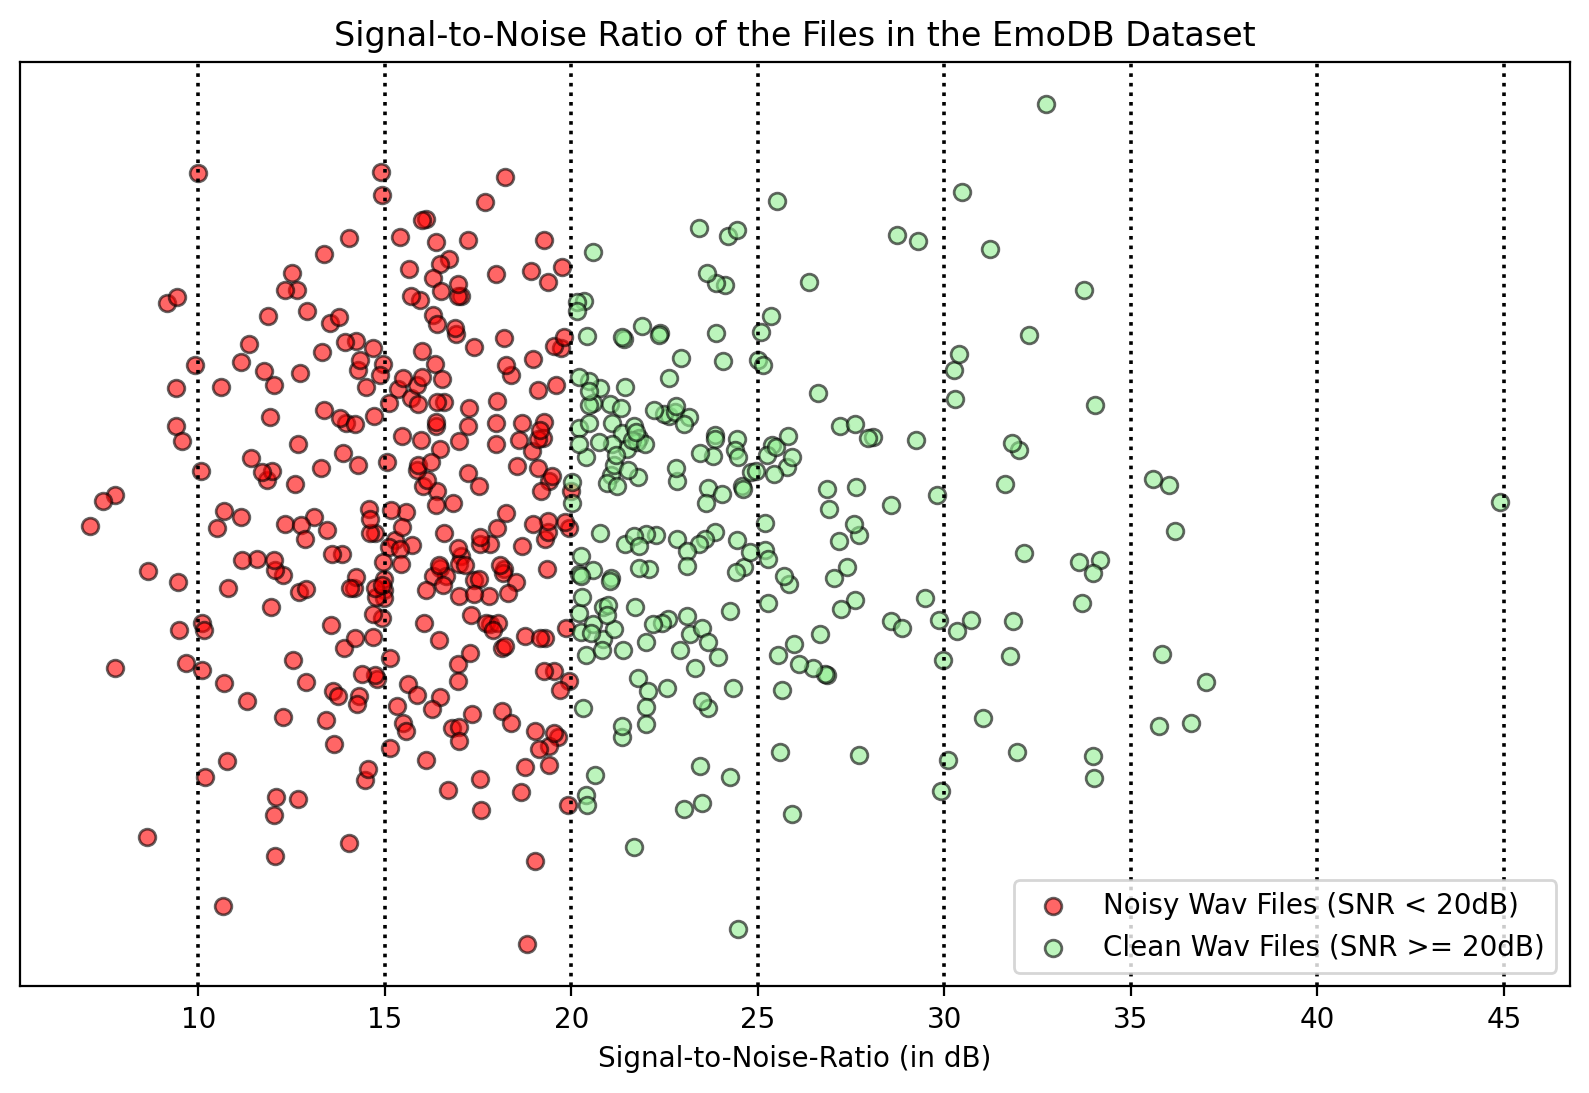

In [16]:
noisy_snr_values = [x[1] for x in noisy_files]
ynoisy = np.random.normal(0, 0.04, size= len(noisy_snr_values))
yclean= np.random.normal(0, 0.04, size=len(clean_snr_values))

plt.figure(figsize=(10,6), dpi = 200)
plt.scatter(noisy_snr_values, ynoisy, color="r", label="Noisy Wav Files (SNR < 20dB)", alpha=0.6, edgecolors="k")
plt.scatter(clean_snr_values, yclean, color="lightgreen", label="Clean Wav Files (SNR >= 20dB)", alpha=0.6, edgecolors="k")

plt.xlabel("Signal-to-Noise-Ratio (in dB)")
plt.title("Signal-to-Noise Ratio of the Files in the EmoDB Dataset")
plt.legend(loc="lower right")
plt.grid(axis="x", ls=":", color="k", linewidth= 1.3, zorder=0)

plt.gca().axes.get_yaxis().set_visible(False)


plt.savefig(r"C:\file\save\to\EmoDB_Emo_SNR_File_Distrbution.png")
plt.show()

In [27]:
noisy_files_10db = []
for file, snr_db in noisy_files:
    if snr_db <= 10.0: 
        noisy_files_10db.append(file)
        perc_files_10db = len(noisy_files_10db)/299 *100

print(f"Noisy files =< 10dB: {perc_files_10db:.2f} %")
    
    

Noisy files =< 10dB: 5.35 %


In [30]:
noisy_files_15db = []
for file, snr_db in noisy_files:
    if snr_db <= 15.0: 
        noisy_files_15db.append(file)
        perc_files_15db = len(noisy_files_15db)/299 *100

print(f"Noisy files =< 15dB: {perc_files_15db:.2f} %")
    

Noisy files =< 15dB: 41.47 %


In [31]:
noisy_files_19db = []
for file, snr_db in noisy_files:
    if snr_db <= 19.0: 
        noisy_files_19db.append(file)
        perc_files_19db = len(noisy_files_19db)/299 *100

print(f"Noisy files =< 19dB: {perc_files_19db:.2f} %")

Noisy files =< 19dB: 87.29 %


In [32]:
clean_files_25dB = []
for file, snr_db in clean_files:
    if snr_db <= 25.0: 
        clean_files_25dB.append(file)
        perc_files_25db = len(clean_files_25dB)/236 *100

print(f"Clean files =< 25dB: {perc_files_25db:.2f} %")

Clean files =< 25dB: 62.29 %


In [34]:
clean_files_37dB = []
for file, snr_db in clean_files:
    if snr_db <= 37.0: 
        clean_files_37dB.append(file)
        perc_files_37db = len(clean_files_37dB)/236 *100

print(f"Clean files =< 37dB: {perc_files_37db:.2f} %")

Clean files =< 37dB: 99.58 %


>> Findings:
>> among the noisy files, only 5.35% are =< 10dB and more than half of the noisy files are > 15dB.   
>> the majority of clean files is centered between 20dB and 25dB, while at 37dB almost all file's noise ratio has been reached, except for one outlier at 44.88dB (mean for clean files is 24.88dB)

### Further extracting information from the data 

#### Measuring the silence ratio per emotion

In [15]:
def silence_ratio(wav_path, energy_treshold_db= -40):
    data,sr = sf.read(wav_path)
    frame_len = int(sr*0.02)
    
    # converting to dB: 20 * np.log10(RMS + 1e-10), using 1e-10 to avoid log10(0)
    energies=[20*np.log10(np.sqrt(np.mean(data[i:i+frame_len]**2))+1e-10) for i in range(0, len(data) - frame_len, frame_len)] 
    silent=sum(e<energy_treshold_db for e in energies)
    return silent/len(energies)

In [16]:
df_whole["filepath"] = df_whole.index.map(lambda f: str(Path(wav_dir)/Path(f).name))
df_whole["silence_ratio"] = df_whole["filepath"].apply(silence_ratio)

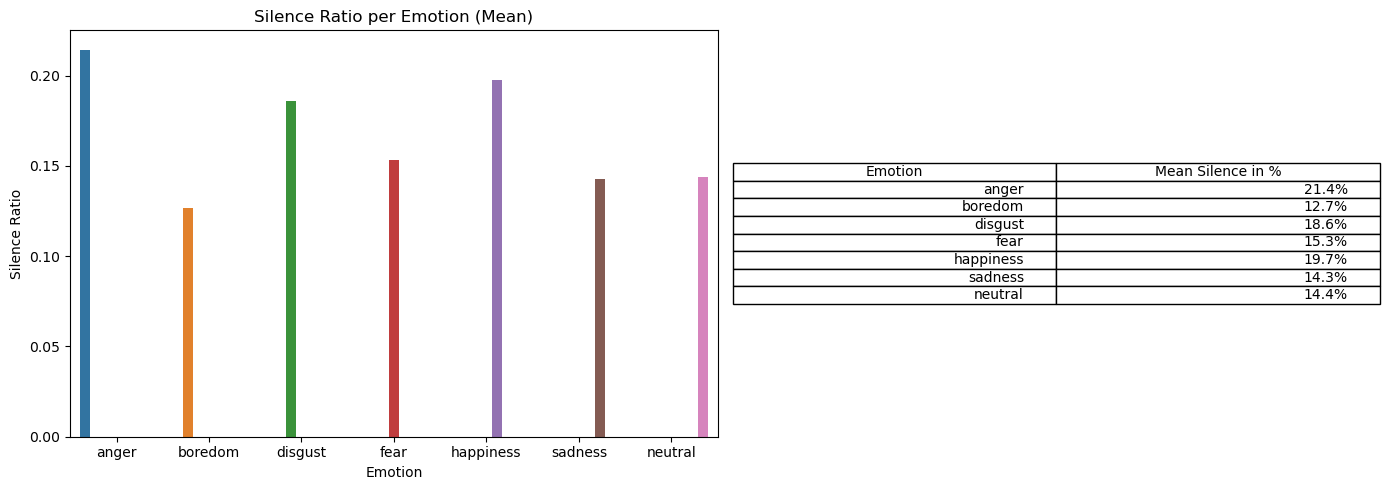

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

silence_per_emotion = df_whole.groupby("emotion")["silence_ratio"].mean().reset_index()
sns.barplot(data=silence_per_emotion, x="emotion", y="silence_ratio",
            hue="emotion", ax=axes[0])
axes[0].set_title("Silence Ratio per Emotion (Mean)")
axes[0].set_ylabel("Silence Ratio")
axes[0].set_xlabel("Emotion")

silence_table = silence_per_emotion.copy()
silence_table["silence_ratio"] = (silence_table["silence_ratio"] * 100).round(1).astype(str) + "%"
axes[1].axis("off")
axes[1].table(cellText=silence_table.values,
              colLabels=["Emotion", "Mean Silence in %"],
              loc="center")

plt.tight_layout()
plt.show()

>> Finding: the average amount of silence per emotion ranges from 12.7-21.4% which suggests that a classifier might not consider silence as a strong discriminating factor since this is a rather narrow span; could this be a result of the emotions not flowing naturally but rather acted? 

#### Checking for wav file length (mean)

In [20]:
import librosa
durations = []
for wav in Path(wav_dir).glob("*.wav"):
    duration = librosa.get_duration(path=wav)
    durations.append(duration)

average_duration = sum(durations) / len(wav_files)
print(f"Average wav file duration: {average_duration:.2f} seconds")

Average wav file duration: 2.78 seconds
